# FIGS — Training Diagnostics

Dataset composition (split sizes, class balance per hazard/lead band), held-out
validation skill per model, and calibration (reliability) curves.

mlx-boosting fits in one shot (no per-iteration loss trace); this notebook focuses
on the validation-set diagnostics that matter for guidance products.

In [1]:
# Run with the `met` conda env kernel.
import warnings; warnings.filterwarnings('ignore')
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, '..')   # so `import figs` works from notebooks/
from figs import config as C

In [2]:
from figs.data.dataset import read_dataset, dataset_feature_columns
from figs.model.wrapper import GBDTModel
from figs.model.calibrate import Calibrator, reliability_ci, low_dense_edges
from figs.config import LEAD_BANDS, HAZARDS
from sklearn.metrics import roc_auc_score, average_precision_score
from pathlib import Path

import json
DATA   = '../Data/processed/figs_v2.parquet'   # MUST be the dataset the models were trained on
MODELS = '../Data/models'
VAL_SAMPLE = 1_000_000  # cap rows pulled per band for skill/reliability

# Feature list comes from the MODELS' own feature_cols.json (written at train
# time) so it always matches what the models expect, in the right order. DATA
# must be the parquet those models were trained on (else the columns won't line
# up -> the '778 vs 5086 features' error). We never load the full feature set:
# counts use only the small label/split/fxx columns.
feats = json.loads((Path(MODELS)/'feature_cols.json').read_text())
missing = [c for c in feats if c not in set(dataset_feature_columns(DATA))]
if missing:
    raise ValueError(f'{len(missing)} model features absent from DATA (e.g. {missing[:3]}); '
                     f'point DATA at the dataset these models were trained on')

# Bag-aware loading: a band/hazard is either a single hazard_{h}_{tag}.pkl or
# a bagged set hazard_{h}_{tag}_bag*.pkl (--bags); average the bags' raw p, as
# predict_valid does. These helpers make the skill/reliability cells work for both.
def band_tags(h):
    return [bb.name for bb in LEAD_BANDS
            if (Path(MODELS)/f'hazard_{h}_{bb.name}.pkl').exists()
            or list(Path(MODELS).glob(f'hazard_{h}_{bb.name}_bag*.pkl'))]
def bag_pred(h, tag, X):
    paths = (sorted(Path(MODELS).glob(f'hazard_{h}_{tag}.pkl'))
             or sorted(Path(MODELS).glob(f'hazard_{h}_{tag}_bag*.pkl')))
    if not paths: return None
    return np.mean([GBDTModel.load(p).predict_pos(X) for p in paths], axis=0)

label_cols = list(HAZARDS) + [h+'_sig' for h in HAZARDS]
meta = read_dataset(DATA, columns=label_cols + ['split','fxx'])
print(f'{len(meta):,} rows | {len(feats)} model features (from feature_cols.json)')

11,650,822 rows | 5086 model features (from feature_cols.json)


## Split sizes and class balance (metadata only)

In [3]:
print(meta.split.value_counts())
for h in HAZARDS:
    print(f'{h:5s} positives: {100*meta[h].mean():.3f}%% ({meta[h].sum():,})  sig: {meta[h+"_sig"].sum():,}')

split
train         8527566
validation    1815957
test          1307299
Name: count, dtype: int64
tor   positives: 0.721%% (84,050)  sig: 19,166
wind  positives: 8.011%% (933,336)  sig: 106,889
hail  positives: 2.713%% (316,099)  sig: 61,259


## Positive rate by lead band and hazard

In [4]:
if 'fxx' in meta:
    rows = []
    for b in LEAD_BANDS:
        sub = meta[(meta.fxx>=b.fmin)&(meta.fxx<=b.fmax)]
        rows.append({'band': b.name, **{h: round(100*sub[h].mean(),3) for h in HAZARDS}, 'n': len(sub)})
    display(pd.DataFrame(rows))

,band,tor,wind,hail,n
0,f1_6,0.724,7.983,2.739,3831270
1,f7_12,0.728,8.026,2.710,3906162
2,f13_18,0.712,8.023,2.691,3913390
3,f19_24,NaN,NaN,NaN,0
4,f25_30,NaN,NaN,NaN,0
5,f31_36,NaN,NaN,NaN,0
6,f37_42,NaN,NaN,NaN,0
7,f43_48,NaN,NaN,NaN,0


## Held-out validation skill per hazard × band (streamed, sampled per band)

In [5]:
def load_split(b, cols, split='validation'):
    f = [('fxx','>=',b.fmin), ('fxx','<=',b.fmax), ('split','==',split)]
    d = read_dataset(DATA, filters=f, columns=cols)
    return d.sample(VAL_SAMPLE, random_state=0) if len(d) > VAL_SAMPLE else d

rows = []
for b in LEAD_BANDS:
    va = load_split(b, feats + list(HAZARDS))
    if len(va) == 0: continue
    Xva = va[feats].to_numpy('float32')
    for h in HAZARDS:
        if va[h].nunique()<2: continue
        p = bag_pred(h, b.name, Xva)          # avg over bags (or the single model)
        if p is None: continue
        cp = Path(MODELS)/f'calib_{h}_{b.name}.pkl'
        if cp.exists(): p = Calibrator.load(cp).transform(p)
        y = va[h].to_numpy(int)
        rows.append({'hazard':h,'band':b.name,'AUC':round(roc_auc_score(y,p),3),
                     'AUPRC':round(average_precision_score(y,p),3),'n':len(va),'pos':int(y.sum())})
    del va, Xva  # free this band before the next
skill = pd.DataFrame(rows)
display(skill)

,hazard,band,AUC,AUPRC,n,pos
0,tor,f1_6,0.981,0.439,605226,6904
1,wind,f1_6,0.979,0.779,605226,45923
2,hail,f1_6,0.980,0.545,605226,17960
3,tor,f7_12,0.979,0.436,605726,6841
4,wind,f7_12,0.977,0.778,605726,46425
5,hail,f7_12,0.978,0.525,605726,17769
6,tor,f13_18,0.977,0.409,605005,6878
7,wind,f13_18,0.977,0.763,605005,45577
8,hail,f13_18,0.976,0.504,605005,18070


## AUC / AUPRC vs lead band, by hazard

How each hazard's skill changes with forecast lead. The dashed/dotted lines are the
published **nadocast (NC 12Z)** and **SPC (1630Z)** HREF-only ROC-AUC benchmarks
(155 days, 2019/1–2022/5) as a reference. Note those are whole-forecast AUCs, so they
compare most directly to our short-lead bands.

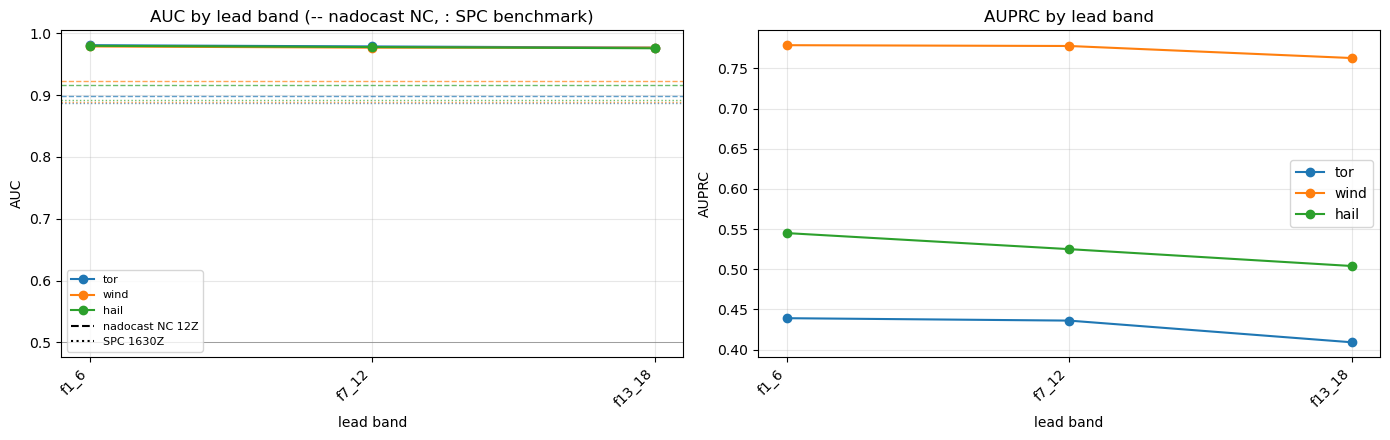

In [6]:
# nadocast NC 12Z / SPC 1630Z HREF-only AUC benchmarks (155 days, 2019-2022)
REFERENCE_AUC = {'tor':  {'NC': 0.899, 'SPC': 0.888},
                 'wind': {'NC': 0.923, 'SPC': 0.889},
                 'hail': {'NC': 0.916, 'SPC': 0.892}}
order = [b.name for b in LEAD_BANDS if b.name in set(skill.band)]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for metric, ax in zip(['AUC', 'AUPRC'], axes):
    for h in HAZARDS:
        s = skill[skill.hazard == h].set_index('band').reindex(order)
        line, = ax.plot(range(len(order)), s[metric], 'o-', label=h)
        if metric == 'AUC':
            c = line.get_color()
            ax.axhline(REFERENCE_AUC[h]['NC'], color=c, ls='--', lw=1, alpha=0.7)
            ax.axhline(REFERENCE_AUC[h]['SPC'], color=c, ls=':', lw=1, alpha=0.7)
    ax.set_xticks(range(len(order))); ax.set_xticklabels(order, rotation=45, ha='right')
    ax.set_xlabel('lead band'); ax.set_ylabel(metric); ax.grid(alpha=0.3); ax.legend()
axes[0].axhline(0.5, color='gray', ls='-', lw=0.5)  # AUC no-skill
axes[0].plot([], [], 'k--', label='nadocast NC 12Z'); axes[0].plot([], [], 'k:', label='SPC 1630Z')
axes[0].legend(fontsize=8, loc='lower left')
axes[0].set_title('AUC by lead band (-- nadocast NC, : SPC benchmark)')
axes[1].set_title('AUPRC by lead band')
plt.tight_layout(); plt.show()

## Validation positives per band (skill is noisier where positives are few)

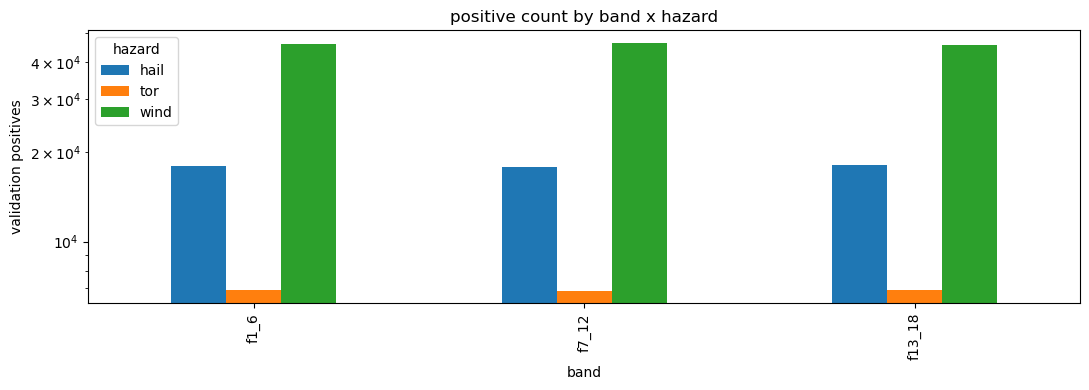

hazard,hail,tor,wind
band,,,
f1_6,17960.0,6904.0,45923.0
f7_12,17769.0,6841.0,46425.0
f13_18,18070.0,6878.0,45577.0


In [7]:
piv = skill.pivot_table(index='band', columns='hazard', values='pos').reindex(order)
piv.plot.bar(figsize=(11,4)); plt.ylabel('validation positives'); plt.yscale('log')
plt.title('positive count by band x hazard'); plt.tight_layout(); plt.show()
display(piv)

## Reliability (calibration) curves — all-band ensemble, held-out TEST split, weighted

Replicates what `predict_valid` actually ships: every forecast hour averages the
**calibrated** predictions of **all** trained lead-band models (a lead-diverse ensemble).
We do the same here — apply every band's model to the test rows and average — instead of
scoring a single band. Averaging 8 independently-clustered tree ensembles fills in the gaps
between leaf values, so the operational curve is far smoother than any one band's.

Evaluated on the **test** split (calibrators were fit on *validation*, so scoring them on
validation would be circular), **weighted** by the subsample-reweighting weights so
'observed freq' is the TRUE climatological rate. A calibrated curve should hug the diagonal.
The number above each calibrated point is that bin's positive count (drives CI width).

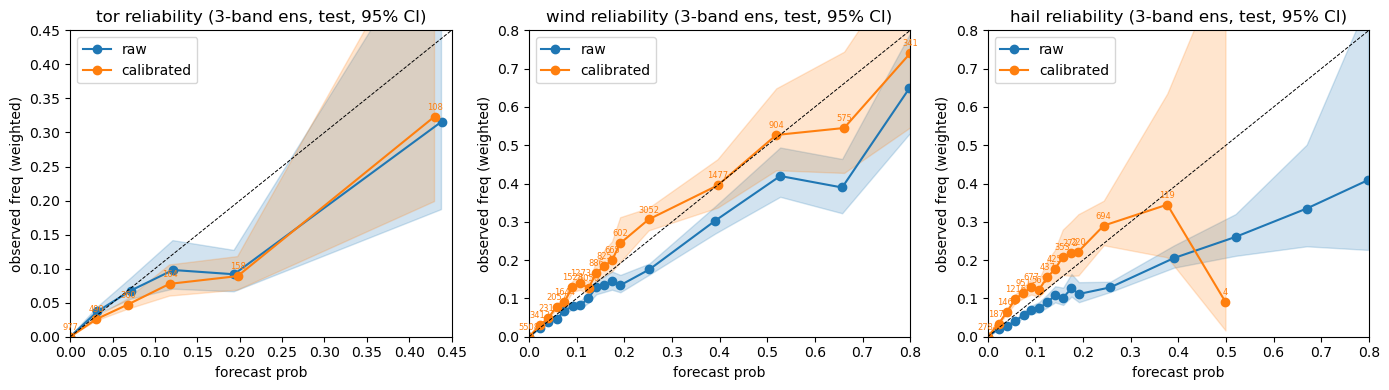

In [8]:
# Per-hazard binning/range: tor has ~10x fewer positives -> custom edges
# matched to SPC tor levels (fine at the bottom); wind/hail denser to 0.8.
REL_EDGES = {'tor':  np.array([0, 0.02, 0.05, 0.10, 0.15, 0.30, 0.45]),
             'wind': low_dense_edges(n_low=12, n_high=6, split=0.20),
             'hail': low_dense_edges(n_low=12, n_high=6, split=0.20)}
REL_XMAX = {'tor': 0.45, 'wind': 0.8, 'hail': 0.8}

# Evaluate on a representative test sample (one band's test rows); the labels are
# valid-time occurrence, and every band model is applied to them just as in production.
b = LEAD_BANDS[0]
te = load_split(b, feats + list(HAZARDS) + ['weight'], split='test')
Xte = te[feats].to_numpy('float32'); w = te['weight'].to_numpy('float32')

def ensemble_preds(h):
    '''All-band ensemble (raw, calibrated) for hazard h on Xte, matching predict_valid.'''
    tags = band_tags(h)
    raw_stack, cal_stack = [], []
    for tag in tags:
        pm = bag_pred(h, tag, Xte)            # avg over bags (or the single model)
        raw_stack.append(pm)
        cp = Path(MODELS)/f'calib_{h}_{tag}.pkl'
        cal_stack.append(Calibrator.load(cp).transform(pm) if cp.exists() else pm)
    if not raw_stack: return None, None, tags
    return np.mean(raw_stack, axis=0), np.mean(cal_stack, axis=0), tags

fig, axes = plt.subplots(1, 3, figsize=(14,4))
for ax,h in zip(axes, HAZARDS):
    p, pc, tags = ensemble_preds(h)
    if p is None or te[h].nunique()<2:
        ax.set_title(f'{h}: n/a'); continue
    y = te[h].to_numpy(int)
    for label,pp in [('raw',p),('calibrated',pc)]:
        mb,ob,lo,hi,_,npos = reliability_ci(pp, y, sample_weight=w, edges=REL_EDGES[h], n_boot=300)
        line, = ax.plot(mb, ob, 'o-', label=label)
        ax.fill_between(mb, lo, hi, color=line.get_color(), alpha=0.2)  # 95% bootstrap CI
        if label=='calibrated':  # annotate # of positives per bin (drives CI width)
            for x,yv,nn in zip(mb,ob,npos):
                ax.annotate(f'{nn}', (x,yv), textcoords='offset points', xytext=(0,5),
                            ha='center', fontsize=6, color=line.get_color())
    ax.plot([0,1],[0,1],'k--',lw=0.7); ax.set_xlabel('forecast prob'); ax.set_ylabel('observed freq (weighted)')
    ax.set_xlim(0, REL_XMAX[h]); ax.set_ylim(0, REL_XMAX[h])  # tor 0-0.45, wind/hail 0-0.8
    ax.set_title(f'{h} reliability ({len(tags)}-band ens, test, 95% CI)'); ax.legend()
plt.tight_layout(); plt.show()